<h1> Frozen vs Fresh Food - What's Better?? </h1>
<h4> Group Wilbur Atwater | EEP 153 Spring 2026 | Subsistence Diet Cost Project </h4>
<h5> Authors: Rishi Boddu, Daniel Canales, Daniel Do, Sage Tulabing, Graze Zhang </h5>
<br/>
<p>In this project, we are going to be looking at frozen meals from Trader Joes and analyzing their nutritional value. We have been provided recommended minimum and maximum intake levels for several nutrients. However, the Trader Joe’s frozen meals do not provide values for every micronutrient included in the dietary guidelines. To reflect realistic choices made by college students who rely on frozen meals, we limit our analysis to the nutritional information that is available for these products. Using this data, we apply a cost-minimization model to identify the lowest-cost combination of Trader Joe’s frozen meals that meets the available nutritional requirements. After determining this minimum-cost meal plan, we then recreate the meals from scratch using fresh ingredients and compare both the price and nutritional value to evaluate whether cooking from raw ingredients offers a better alternative.</p>

<h3>[A] Population of Interest </h3>
<p> Our population of interest is college students, because they are one of the most likely groups to rely on frozen meals. Students often face time constraints, limited cooking access (shared kitchens, dorms), and tight budgets, soso they prioritize foods that are fast, affordable, and low-effort. Frozen meals fit this lifestyle: they’re widely available, have predictable pricing, and require minimal prep. This makes college students a realistic demographic for studying the tradeoff between cost, convenience, and meeting basic nutrition needs using packaged meals.</p>

<h4> Imports and Cleaning Data </h4>

In [38]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog as lp
import matplotlib.pyplot as plt
import warnings


# CSV FILES
# dietary minimums for diff sex and age ranges, various micronutrients
mins = pd.read_csv("diet_minimums.csv")
# load dietary maximums for diff sex and age ranges, sodium and calories
maxs = pd.read_csv("diet_maximums.csv")
#trader joes meal price and nutritional info
tjs_df = pd.read_csv("tjs_nutrients.csv")


# CLEANING UP DATA

# setting the first column of max and min csv files (nutrient name) as the index and cleaning up whitespace
mins = mins.set_index(mins.columns[0])
maxs = maxs.set_index(maxs.columns[0])
mins.index = mins.index.astype(str).str.strip()
maxs.index = maxs.index.astype(str).str.strip()
mins = mins.apply(pd.to_numeric, errors="coerce")
maxs = maxs.apply(pd.to_numeric, errors="coerce")

# cleaning up TJ meals columns to only include meal name, price, and nutrients that are the same between constrain csv and the tjs csv
FOOD_COL  = "Meal"
PRICE_COL = "Price"
tjs_df.columns = tjs_df.columns.astype(str).str.strip()
nutrient_names = sorted(set(mins.index).union(set(maxs.index)))
nutrient_cols = [c for c in tjs_df.columns if c in nutrient_names]
tjs = tjs_df[[FOOD_COL, PRICE_COL] + nutrient_cols]

<h3>[A] Data on Prices AND Nutrional Content of Different Foods </h3>
<p>We've compiled the following CSV file containing pricing and nutritional info about several frozen meals listed on the official Trader Joes website. </p>

In [39]:
tjs.head()

,Meal,Price,Energy,"Carbohydrate, by difference","Sodium, Na","Fiber, total dietary",Protein,"Calcium, Ca","Iron, Fe","Potassium, K"
0,Chicken Tikka Masala,4.790000,360,39,580,1,21,120,6.125,0
1,Vegetable Spring Rolls,1.796000,200,24,400,5,5,60,0.700,200
2,Roasted Garlic & Pesto Pizza with Deep Fried C...,2.163333,430,43,900,3,17,260,1.200,170
3,Butter Chicken with Basmati Rice,4.490000,400,49,640,2,24,50,1.800,530
4,Mini Beef Tacos,1.298000,230,27,330,3,8,60,1.500,180


<h3>[A] The Solution - Min Cost Diet </h3>

In [40]:
tjs_df[FOOD_COL] = tjs_df[FOOD_COL].astype(str).str.strip()

nutrient_names = sorted(set(mins.index).union(set(maxs.index)))
nutrient_cols = [c for c in tjs_df.columns if c in nutrient_names]

tjs = tjs_df[[FOOD_COL, PRICE_COL] + nutrient_cols].copy()


tjs[nutrient_cols] = tjs[nutrient_cols].apply(pd.to_numeric, errors="coerce").fillna(0)


tjs = tjs.drop_duplicates(subset=[FOOD_COL], keep="first")


Prices = pd.to_numeric(tjs[PRICE_COL], errors="coerce")
Prices.index = tjs[FOOD_COL].astype(str).str.strip()

FoodNutrients = tjs.set_index(FOOD_COL)[nutrient_cols].T
FoodNutrients = FoodNutrients.apply(pd.to_numeric, errors="coerce").fillna(0)


FoodNutrients = FoodNutrients.loc[:, Prices.index.intersection(FoodNutrients.columns)]
Prices = Prices.loc[FoodNutrients.columns]



def solve_subsistence_problem(FoodNutrients, Prices, dietmin, dietmax=None, max_weight=None, tol=1e-6):


    p = Prices.dropna().copy()


    foods = p.index.intersection(FoodNutrients.columns)
    p = p.loc[foods]


    Aall = FoodNutrients.loc[:, foods].fillna(0)


    dietmin_use = dietmin.dropna()

    if dietmax is None:
        dietmax_use = pd.Series(dtype=float)
    else:
        dietmax_use = dietmax.dropna()

    dietmin_use = dietmin_use.loc[dietmin_use.index.intersection(Aall.index)]
    dietmax_use = dietmax_use.loc[dietmax_use.index.intersection(Aall.index)]

    if len(dietmin_use) == 0 and len(dietmax_use) == 0:
        raise ValueError("No enforceable nutrient constraints (check nutrient names).")

    # Build A_ub x <= b_ub
    A_ub_list = []
    b_ub_list = []

    # mins: A x >= b  ->  -A x <= -b
    if len(dietmin_use) > 0:
        Amin = Aall.loc[dietmin_use.index]
        A_ub_list.append((-Amin).to_numpy())
        b_ub_list.append((-dietmin_use).to_numpy())
    else:
        Amin = pd.DataFrame(index=[], columns=Aall.columns)


    if len(dietmax_use) > 0:
        Amax = Aall.loc[dietmax_use.index]
        A_ub_list.append((Amax).to_numpy())
        b_ub_list.append((dietmax_use).to_numpy())
    else:
        Amax = pd.DataFrame(index=[], columns=Aall.columns)

    A_ub = np.vstack(A_ub_list) if len(A_ub_list) > 0 else None
    b_ub = np.concatenate(b_ub_list) if len(b_ub_list) > 0 else None


    if max_weight is not None:
        if A_ub is None:
            A_ub = np.ones((1, len(p)))
            b_ub = np.array([max_weight])
        else:
            A_ub = np.vstack([A_ub, np.ones(len(p))])
            b_ub = np.concatenate([b_ub, [max_weight]])


    result = lp(c=p.to_numpy(),
                A_ub=A_ub, b_ub=b_ub,
                bounds=[(0, None)] * len(p),
                method="highs")

    result.foods = p.index
    result.Amin = Amin
    result.Amax = Amax
    result.dietmin = dietmin_use
    result.dietmax = dietmax_use

    if result.success:
        diet = pd.Series(result.x, index=p.index)
        diet[diet.abs() < tol] = 0.0
        result.diet = diet.sort_values(ascending=False)
        result.cost = float(result.fun)

        if len(dietmin_use) > 0:
            result.outcomes_min = pd.Series(Amin.to_numpy().dot(result.x), index=Amin.index)
        else:
            result.outcomes_min = pd.Series(dtype=float)

        if len(dietmax_use) > 0:
            result.outcomes_max = pd.Series(Amax.to_numpy().dot(result.x), index=Amax.index)
        else:
            result.outcomes_max = pd.Series(dtype=float)
    else:
        warnings.warn(result.message)
        result.diet = pd.Series(np.nan, index=p.index)
        result.cost = np.nan
        result.outcomes_min = pd.Series(dtype=float)
        result.outcomes_max = pd.Series(dtype=float)

    return result


group = "M 19-30" 
dietmin = mins[group]
dietmax = maxs[group] 

res = solve_subsistence_problem(FoodNutrients, Prices, dietmin, dietmax=None, tol=1e-6)

if not res.success:
    print("Infeasible (mins-only):", res.message)
else:
    print(f"Cost of diet for {group} (mins-only): ${res.cost:.2f} per day\n")
    print("Diet (servings per day):")
    display(res.diet[res.diet > 0].to_frame("Servings"))

    tab_min = pd.DataFrame({"Achieved": res.outcomes_min, "Required (min)": res.dietmin})
    tab_min["Slack"] = tab_min["Achieved"] - tab_min["Required (min)"]
    display(tab_min.sort_values("Slack"))

Cost of diet for M 19-30 (mins-only): $11.85 per day

Diet (servings per day):


,Servings
Meal,
Bulgur Pilaf with Butternut Squash & Feta Cheese,16.213152
Family Style Meat Lasagna,1.405896


,Achieved,Required (min),Slack
"Potassium, K",4700.000000,4700.0,0.000000e+00
"Calcium, Ca",1000.000000,1000.0,1.136868e-13
"Fiber, total dietary",35.238095,33.6,1.638095e+00
"Iron, Fe",18.462585,8.0,1.046259e+01
Protein,126.802721,56.0,7.080272e+01
"Carbohydrate, by difference",360.816327,130.0,2.308163e+02
Energy,3692.517007,2400.0,1.292517e+03


In [41]:

group = "M 19-30"

dietmin = mins[group]


dietmax_sodium = maxs[group].loc[["Sodium, Na"]]

res = solve_subsistence_problem(FoodNutrients, Prices, dietmin, dietmax=dietmax_sodium, tol=1e-6)

if not res.success:
    print("Infeasible (mins + sodium):", res.message)
else:
    print(f"Cost of diet for {group} (mins + sodium): ${res.cost:.2f} per day\n")

    print("Diet (servings per day):")
    display(res.diet[res.diet > 0].to_frame("Servings"))

    tab_min = pd.DataFrame({"Achieved": res.outcomes_min, "Required (min)": res.dietmin})
    tab_min["Slack"] = tab_min["Achieved"] - tab_min["Required (min)"]
    display(tab_min.sort_values("Slack"))


    tab_max = pd.DataFrame({"Achieved": res.outcomes_max, "Required (max)": res.dietmax})
    tab_max["Slack"] = tab_max["Required (max)"] - tab_max["Achieved"]
    display(tab_max.sort_values("Slack"))

Cost of diet for M 19-30 (mins + sodium): $21.12 per day

Diet (servings per day):


,Servings
Meal,
Fruits & Greens Smoothie Blend,9.014116
Steel Cut Oatmeal,4.147251
Bulgur Pilaf with Butternut Squash & Feta Cheese,3.659612
Palak Paneer,1.151979


,Achieved,Required (min),Slack
Energy,2400.000000,2400.0,0.000000
"Calcium, Ca",1000.000000,1000.0,0.000000
"Potassium, K",4700.000000,4700.0,0.000000
"Iron, Fe",18.358959,8.0,10.358959
Protein,72.241951,56.0,16.241951
"Fiber, total dietary",64.572609,33.6,30.972609
"Carbohydrate, by difference",391.687543,130.0,261.687543


,Achieved,Required (max),Slack
"Sodium, Na",2300.0,2300,0.0


<h3>[A] Dietary Reference Intakes</h3>
<p>This function takes a person's age and sex as arguments and returns a series of daily reccomended dietary intake amounts for a variety of nutrients. </p>

In [42]:
# helper function to determine the right age group
def age_bucket(age):
    age = float(age)
    if age <= 3:
        return "C 1-3"
    elif age <= 8:
        return "4-8"
    elif age <= 13:
        return "9-13"
    elif age <= 18:
        return "14-18"
    elif age <= 30:
        return "19-30"
    elif age <= 50:
        return "31-50"
    else:
        return "51+"

In [43]:
def dietary_requirements(age, sex):
    bucket = age_bucket(age)

    # if the column isnt "C 1-3" then it has to be built using the inputted sex and the age group returned by our helper func
    if bucket == "C 1-3":
        col = "C 1-3"
    else:
        col = f"{sex} {bucket}"

    # minimums + maximums for that column
    s_min = mins[col].copy()
    s_max = maxs[col].copy()

    # combine Energy min + max into one range
    if "Energy" in s_min.index and "Energy" in s_max.index:
        energy_min = s_min["Energy"]
        energy_max = s_max["Energy"]
    
        # convert Series to object so it can hold strings
        s_min = s_min.astype(object)
    
        s_min["Energy"] = f"{int(energy_min)} - {int(energy_max)}"
        s_max = s_max.drop("Energy")

    # label remaining maximums
    s_max = s_max.rename(lambda x: f"{x} (MAX)")

    out = pd.concat([s_min, s_max])
    out.name = f"Requirements for {sex}, age {age} (col={col})"
    return out

In [44]:
# example usage of the code
req = dietary_requirements(age = 40, sex = "F")
req

Nutrition
Energy                            1800 - 3100
Protein                                  46.0
Fiber, total dietary                     25.2
Folate, DFE                             400.0
Calcium, Ca                            1000.0
Carbohydrate, by difference             130.0
Iron, Fe                                 18.0
Magnesium, Mg                           320.0
Niacin                                   14.0
Phosphorus, P                           700.0
Potassium, K                           4700.0
Riboflavin                                1.1
Thiamin                                   1.1
Vitamin A, RAE                          700.0
Vitamin B-12                              2.4
Vitamin B-6                               1.3
Vitamin C, total ascorbic acid           75.0
Vitamin E (alpha-tocopherol)             15.0
Vitamin K (phylloquinone)                90.0
Zinc, Zn                                  8.0
Sodium, Na (MAX)                         2300
Name: Requirements for F

In [45]:
# tests for this function

# test 1: function returns a pandas Series
def test_returns_series():
    result = dietary_requirements(25, "F")
    assert isinstance(result, pd.Series)

# test 2: energy should be displayed as a range
def test_energy_range():
    result = dietary_requirements(25, "F")
    assert "Energy" in result.index
    assert "-" in result["Energy"]

# test 3: ages 1–3 should use the C 1-3 column (no sex prefix)
def test_age_1_3_bucket():
    result = dietary_requirements(2, "F")
    assert "C 1-3" in result.name

# test 4: correct age bucket column is used
def test_age_bucket():
    result = dietary_requirements(30, "M")
    assert "M 19-30" in result.name

# function to run all tests
def run_tests():
    test_returns_series()
    test_energy_range()
    test_age_1_3_bucket()
    test_age_bucket()
    print("All tests passed!")
    
run_tests()

All tests passed!


<h3> How does the minimum nutrients needed grow with age and sex ?? </h3>
<h4> Energy (Calories) </h4>

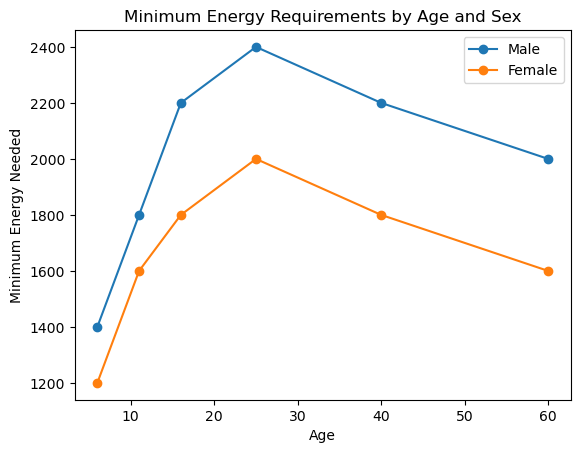

In [46]:
age_points = {
    "4-8": 6,
    "9-13": 11,
    "14-18": 16,
    "19-30": 25,
    "31-50": 40,
    "51+": 60
}

male_energy = []
female_energy = []
ages = []

for bucket, age in age_points.items():
    m_col = f"M {bucket}"
    f_col = f"F {bucket}"
    
    if m_col in mins.columns and f_col in mins.columns:
        male_energy.append(mins.loc["Energy", m_col])
        female_energy.append(mins.loc["Energy", f_col])
        ages.append(age)

plt.figure()
plt.plot(ages, male_energy, marker='o', label="Male")
plt.plot(ages, female_energy, marker='o', label="Female")

plt.xlabel("Age")
plt.ylabel("Minimum Energy Needed")
plt.title("Minimum Energy Requirements by Age and Sex")
plt.legend()

plt.show()

<h4> Fiber </h4>

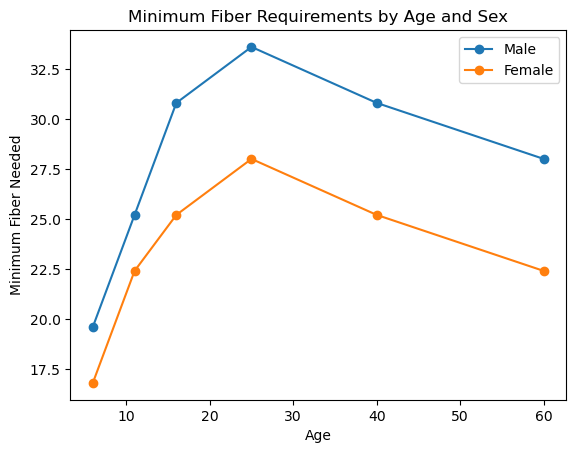

In [47]:
male_fiber = []
female_fiber = []
ages = []

for bucket, age in age_points.items():
    m_col = f"M {bucket}"
    f_col = f"F {bucket}"
    
    if m_col in mins.columns and f_col in mins.columns:
        male_fiber.append(mins.loc["Fiber, total dietary", m_col])
        female_fiber.append(mins.loc["Fiber, total dietary", f_col])
        ages.append(age)

plt.figure()
plt.plot(ages, male_fiber, marker='o', label="Male")
plt.plot(ages, female_fiber, marker='o', label="Female")

plt.xlabel("Age")
plt.ylabel("Minimum Fiber Needed")
plt.title("Minimum Fiber Requirements by Age and Sex")
plt.legend()

plt.show()

<h4> Protein </h4>

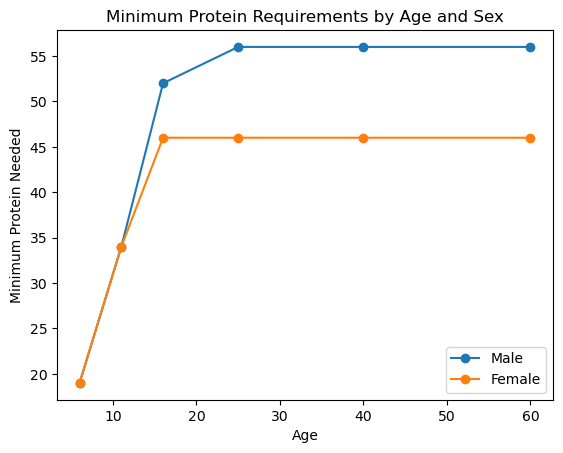

In [48]:
male_protein = []
female_protein = []
ages = []

for bucket, age in age_points.items():
    m_col = f"M {bucket}"
    f_col = f"F {bucket}"
    
    if m_col in mins.columns and f_col in mins.columns:
        male_protein.append(mins.loc["Protein", m_col])
        female_protein.append(mins.loc["Protein", f_col])
        ages.append(age)

plt.figure()
plt.plot(ages, male_protein, marker='o', label="Male")
plt.plot(ages, female_protein, marker='o', label="Female")

plt.xlabel("Age")
plt.ylabel("Minimum Protein Needed")
plt.title("Minimum Protein Requirements by Age and Sex")
plt.legend()

plt.show()